LOCAL BINARY PATTERNS (LBP)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import os
import glob

array([[165, 165, 168, ..., 169, 169, 169],
       [164, 165, 167, ..., 170, 169, 165],
       [162, 164, 165, ..., 167, 166, 165],
       ...,
       [174, 173, 171, ..., 178, 179, 181],
       [175, 172, 170, ..., 179, 178, 178],
       [172, 174, 172, ..., 177, 176, 176]], dtype=uint8)
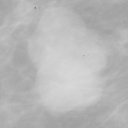

In [2]:
# 1.convert into a grayscale
img=cv.imread('/content/original.png',0)
#img=cv.resize(img,(256,256))
img

1. simple LOcal Binary Patterns

In [3]:
#convolation function
def LBP_Binary_code(kernal_size,image):#without rotation
  #size of kernal && image
  kernal_r,kernal_c=kernal_size,kernal_size
  image_r,image_c=image.shape

  #check how much padding require for img
  padding_r=kernal_r//2 # return the quotient
  padding_c=kernal_c//2

  #apply this padding on given img
  padded_img=np.pad(image,((padding_r,padding_r),(padding_c,padding_c)),mode='constant',constant_values=0)
  resultant_binary_coded_image=np.zeros((image_r,image_c,kernal_r,kernal_c))


  #select region of img accordind to mask/kernal size and made a bianry code and resturn it
  # Select regions of the image based on kernel size
  for i in range(image_r):
    for j in range(image_c):
      region = padded_img[i:i + kernal_r, j:j + kernal_c]
      center_value = region[kernal_r // 2, kernal_c // 2]

      # Generate binary code (store separately)
      binary_code = np.where(region >= center_value, 1, 0)
      binary_code[kernal_r // 2, kernal_c // 2] = 0  # Exclude center
      resultant_binary_coded_image[i, j] = binary_code


  return resultant_binary_coded_image






In [4]:
#intermediate binary code generated
resultant_binary_coded_img=LBP_Binary_code(3,img)
#resultant_binary_coded_img[3,4]

In [5]:
def spiral_traverse_exclude_center_clockwise(img): #clock-wise
    rows = img.shape[0]
    cols = img.shape[1]
    result = []

    # Define the boundaries
    top, bottom, left, right = 0, rows - 1, 0, cols - 1

    # Find the center pixel for exclusion if it's a square matrix with odd dimensions
    center_row, center_col = rows // 2, cols // 2
    has_center = rows % 2 != 0 and rows == cols

    while top <= bottom and left <= right:
        # Traverse from left to right along the top boundary
        for col in range(left, right + 1):
            if not (has_center and top == center_row and col == center_col):  # Skip center
                result.append(img[top,col])
        top += 1

        # Traverse from top to bottom along the right boundary
        for row in range(top, bottom + 1):
            if not (has_center and row == center_row and right == center_col):  # Skip center
                result.append(img[row,right])
        right -= 1

        # Traverse from right to left along the bottom boundary (if still within bounds)
        if top <= bottom:
            for col in range(right, left - 1, -1):
                if not (has_center and bottom == center_row and col == center_col):  # Skip center
                    result.append(img[bottom,col])
            bottom -= 1

        # Traverse from bottom to top along the left boundary (if still within bounds)
        if left <= right:
            for row in range(bottom, top - 1, -1):
                if not (has_center and row == center_row and left == center_col):  # Skip center
                    result.append(img[row,left])
            left += 1

    return result




In [6]:
def spiral_traverse_exclude_center_anticlockwise(img): #anti-clock-wise
    rows = img.shape[0]
    cols = img.shape[1]
    result = []

    # Define the boundaries
    top, bottom, left, right = 0, rows - 1, 0, cols - 1

    # Find the center pixel for exclusion if it's a square matrix with odd dimensions
    center_row, center_col = rows // 2, cols // 2
    has_center = rows % 2 != 0 and rows == cols

    while top <= bottom and left <= right:
        # Traverse from right to left along the top boundary
        for col in range(right,left-1,-1):
            if not (has_center and top == center_row and col == center_col):  # Skip center
                result.append(img[top,col])
        top += 1

        # Traverse from top to bottom along the left boundary
        for row in range(top, bottom + 1):
            if not (has_center and row == center_row and right == center_col):  # Skip center
                result.append(img[row,left])
        left+= 1

        # Traverse from left to right along the bottom boundary (if still within bounds)
        if top <= bottom:
            for col in range(left,right+1):
                if not (has_center and bottom == center_row and col == center_col):  # Skip center
                    result.append(img[bottom,col])
            bottom -= 1

        # Traverse from bottom to top along the right boundary (if still within bounds)
        if left <= right:
            for row in range(bottom,top-1,-1):
                if not (has_center and row == center_row and left == center_col):  # Skip center
                    result.append(img[row,right])
            left += 1

    return result




In [7]:
#convert binary to decimal
def decimal_code(binary_code):
  decimal=0
  size=binary_code.shape[0]-1
  for i in range(binary_code.shape[0]):
    decimal+=binary_code[i]*(2**size)
    size-=1
  return decimal




In [8]:
resultant_decimal=np.zeros((img.shape[0],img.shape[1]))

for i in range(resultant_binary_coded_img.shape[0]):
  for j in range(resultant_binary_coded_img.shape[1]):
    resultant_binary_1d=spiral_traverse_exclude_center_anticlockwise(resultant_binary_coded_img[i,j]) # here you can generate a 1d array with anti-clock-wise patterns also
    resultant_binary_1d=np.array(resultant_binary_1d)

    resultant_decimal[i,j]=decimal_code(resultant_binary_1d)






[[  3.  23.   3. ...  31.  29.  24.]
 [195. 227. 195. ...  48. 240. 124.]
 [199. 231. 227. ... 240. 112. 116.]
 ...
 [ 68. 248. 251. ... 135.  73.   0.]
 [  0. 126. 255. ... 128. 241. 112.]
 [193.  32. 177. ... 240. 241. 112.]]



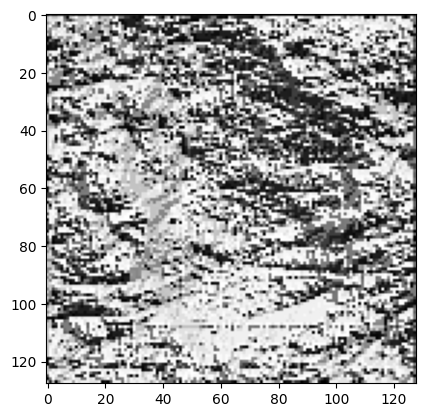

In [9]:
print(resultant_decimal)
print()
plt.imshow(resultant_decimal,cmap='gray')


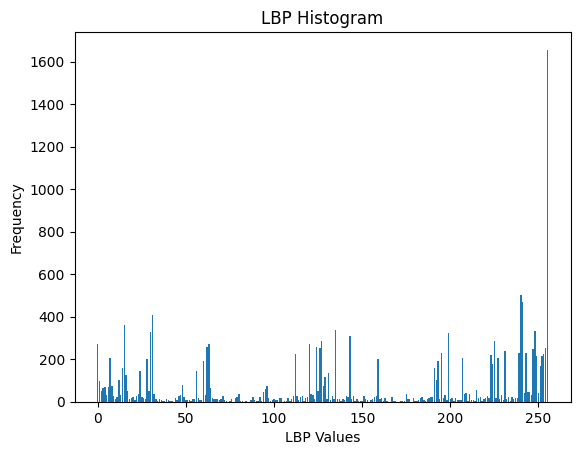

In [10]:
# Compute histogram of LBP values
lbp_histogram = np.histogram(resultant_decimal.flatten(), bins=np.arange(257))
plt.bar(lbp_histogram[1][:-1], lbp_histogram[0])  #
plt.title("LBP Histogram")
plt.xlabel("LBP Values")
plt.ylabel("Frequency")
plt.show()

2. Multi-Scale Local Binary Patterns:

In [11]:
# --->>>>work on bases of r=radius and p=no of point include into a binary code
def tertiary_LBP_code(image,radius):
   #size of kernal && image
  kernal_r,kernal_c=radius,radius
  image_r,image_c=image.shape

  #check how much padding require for img
  padding_r=kernal_r//2 # return the quotient
  padding_c=kernal_c//2

  #apply this padding on given img
  padded_img=np.pad(image,((padding_r,padding_r),(padding_c,padding_c)),mode='constant',constant_values=0)
  resultant_tertiary_coded_image=np.zeros((image_r,image_c,kernal_r,kernal_c))



  const=1
  for i in range(image_r):
    for j in range(image_c):
      region = padded_img[i:i + kernal_r, j:j + kernal_c]
      center_value = region[kernal_r // 2, kernal_c // 2]
      tertiary_code=np.zeros((region.shape[0],region.shape[1]))


      for k in range(region.shape[0]):
        for l in range(region.shape[1]):
          if k==kernal_r//2 and l==kernal_c//2:
            continue
          if(region[k,l]>center_value+const):
            tertiary_code[k,l]=1
          elif(region[k,l]>center_value-const and region[k,l]<center_value+const ):
            tertiary_code[k,l]=0
          elif(region[k,l]<center_value-const):
            tertiary_code[k,l]=-1
      tertiary_code[kernal_r // 2, kernal_c // 2] = 0  # Exclude center

      resultant_tertiary_coded_image[i, j] = tertiary_code


  return resultant_tertiary_coded_image






In [12]:
def upper_binary_code(tertiary_img,radius):
  for i in range(tertiary_img.shape[0]):
    for j in range(tertiary_img.shape[1]):
        region = tertiary_img[i,j]



        for k in range(region.shape[0]):
          for l in range(region.shape[1]):

            if(region[k,l]==-1):
              region[k,l]=0

            else:
              continue

        tertiary_img[i,j]=region



  return tertiary_img





In [13]:
def lower_binary_code(tertiary_img,radius):

  for i in range(tertiary_img.shape[0]):
      for j in range(tertiary_img.shape[1]):
        region = tertiary_img[i,j]



        for k in range(region.shape[0]):
          for l in range(region.shape[1]):

            if(region[k,l]==-1):
              region[k,l]=1

            else:
              region[k,l]=0

        tertiary_img[i,j]=region

      return tertiary_img


In [14]:
# create a decimal code but add only a point p from a region

#x=xcenter+R⋅cos(2πk/P)

#y=ycenter+R⋅sin(P/2πk)

def select_point_and_decimal(binary_code,point,radius): # point select on base of radius and circle creation
    resultant_decimal=np.zeros((img.shape[0],img.shape[1]))


    for i in range(binary_code.shape[0]):
      for j in range(binary_code.shape[1]):
        region=binary_code[i,j]

        xcenter=region.shape[0]//2
        ycenter=region.shape[1]//2
        points=[]

        for k in range(region.shape[0]):
          for l in range(region.shape[1]):


            #take floor int value
            x=int(np.ceil(xcenter+radius*np.cos(2*np.pi*k/point))) # a row pixel by making a circle according to a radius(no of neighbours)
            y=int(np.ceil(ycenter+radius*np.sin(2*np.pi*l/point)))

            # Ensure the coordinates are within the bounds of the region
            if 0 <= x < region.shape[0] and 0 <= y < region.shape[1]:
              points.append(region[x,y]) # retain a selected pixel slected by circle equation and ignore other by placing 0

            if(len(points)==point):
              break

        #now for this respective region generate a decimal code and store into a resultant decimal-code
        points=np.array(points)
        points=points.astype(int)

        resultant_decimal[i,j]=decimal_code(points)

    return resultant_decimal














In [15]:
resultant_tertiary_coded_image=tertiary_LBP_code(img,3)

#generate a upper binary code and lower binary code
upper_binary_img=upper_binary_code(resultant_tertiary_coded_image,3)
lower_binary_img=lower_binary_code(resultant_tertiary_coded_image,3)



In [16]:
upper_binary_decimal=select_point_and_decimal(upper_binary_img,8,3)
lower_binary_decimal=select_point_and_decimal(lower_binary_img,8,3)

In [17]:
#print(upper_binary_decimal[0,0])
#print(lower_binary_decimal)

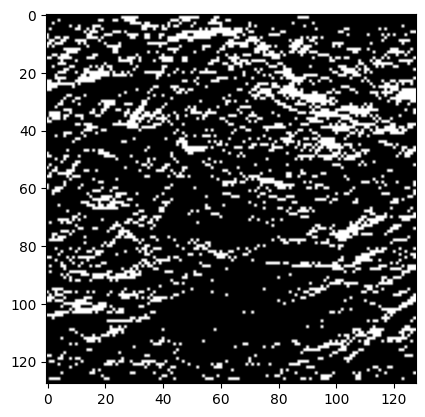

In [18]:
plt.imshow(upper_binary_decimal,cmap='gray')

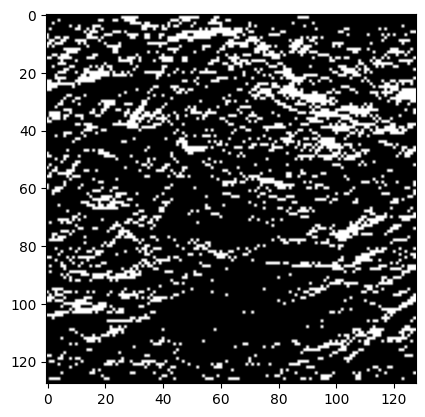

In [19]:
plt.imshow(lower_binary_decimal,cmap='gray')